<a href="https://colab.research.google.com/github/sorel07/think_python/blob/main/chapters/chap06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Puedes comprar las versiones impresa y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py


# Valores de retorno

En capítulos anteriores, hemos usado funciones integradas -- como `abs` y `round` -- y funciones del módulo math -- como `sqrt` y `pow`.
Cuando llamas a una de estas funciones, devuelve un valor que puedes asignar a una variable o usar como parte de una expresión.

Las funciones que hemos escrito hasta ahora son diferentes.
Algunas usan la función `print` para mostrar valores, y otras usan funciones de turtle para dibujar figuras.
Pero no devuelven valores que asignemos a variables o usemos en expresiones.

En este capítulo veremos cómo escribir funciones que devuelven valores.

## Algunas funciones tienen valores de retorno

Cuando llamas a una función como `math.sqrt`, el resultado se llama **valor de retorno**.
Si la llamada a la función aparece al final de una celda, Jupyter muestra inmediatamente el valor de retorno.

In [ ]:
import math

math.sqrt(42 / math.pi)

Si asignas el valor de retorno a una variable, no se muestra.

In [ ]:
radius = math.sqrt(42 / math.pi)

Pero puedes mostrarlo más tarde.

In [ ]:
radius

O puedes usar el valor de retorno como parte de una expresión.

In [ ]:
radius + math.sqrt(42 / math.pi)

Aquí tienes un ejemplo de una función que devuelve un valor.

In [ ]:
def circle_area(radius):
    area = math.pi * radius**2
    return area

`circle_area` toma `radius` como parámetro y calcula el área de un círculo con ese radio.

La última línea es una sentencia `return` que devuelve el valor de `area`.

Si llamamos a la función así, Jupyter muestra el valor de retorno.



In [ ]:
circle_area(radius)

Podemos asignar el valor de retorno a una variable.

In [ ]:
a = circle_area(radius)

O usarlo como parte de una expresión.

In [ ]:
circle_area(radius) + 2 * circle_area(radius / 2)

Más tarde podemos mostrar el valor de la variable a la que asignamos el resultado.

In [ ]:
a

Pero no podemos acceder a `area`.

In [ ]:
%%expect NameError

area

`area` es una variable local dentro de una función, así que no podemos acceder a ella desde fuera de la función.

## Y algunas tienen None

Si una función no tiene una sentencia `return`, devuelve `None`, que es un valor especial como `True` y `False`.
Por ejemplo, aquí está la función `repeat` del Capítulo 3.

In [ ]:
def repeat(word, n):
    print(word * n)

Si la llamamos así, muestra la primera línea de la canción "Finland" de Monty Python.

In [ ]:
repeat('Finland, ', 3)

Esta función usa la función `print` para mostrar una cadena, pero no usa una sentencia `return` para devolver un valor.
Si asignamos el resultado a una variable, muestra la cadena de todos modos.

In [ ]:
result = repeat('Finland, ', 3)

Y si mostramos el valor de la variable, no obtenemos nada.

In [ ]:
result

`result` en realidad tiene un valor, pero Jupyter no lo muestra.
Sin embargo, podemos mostrarlo así.

In [ ]:
print(result)

El valor de retorno de `repeat` es `None`.

Ahora aquí tienes una función parecida a `repeat`, excepto que sí tiene un valor de retorno.

In [ ]:
def repeat_string(word, n):
    return word * n

Observa que podemos usar una expresión en una sentencia `return`, no solo una variable.

Con esta versión, podemos asignar el resultado a una variable.
Cuando la función se ejecuta, no muestra nada.

In [ ]:
line = repeat_string('Spam, ', 4)

Pero más tarde podemos mostrar el valor asignado a `line`.

In [ ]:
line

Una función como esta se llama **función pura** porque no muestra nada ni tiene ningún otro efecto -- aparte de devolver un valor.

## Valores de retorno y condicionales

Si Python no proporcionara `abs`, podríamos escribirla así.

In [ ]:
def absolute_value(x):
    if x < 0:
        return -x
    else:
        return x

Si `x` es negativo, la primera sentencia `return` devuelve `-x` y la función termina inmediatamente.
En caso contrario, la segunda sentencia `return` devuelve `x` y la función termina.
Así que esta función es correcta.

Sin embargo, si pones sentencias `return` en un condicional, tienes que asegurarte de que todos los caminos posibles del programa lleguen a una sentencia `return`.
Por ejemplo, aquí tienes una versión incorrecta de `absolute_value`.

In [ ]:
def absolute_value_wrong(x):
    if x < 0:
        return -x
    if x > 0:
        return x

Esto es lo que ocurre si llamamos a esta función con `0` como argumento.

In [ ]:
absolute_value_wrong(0)

¡No obtenemos nada! Este es el problema: cuando `x` es `0`, ninguna condición es verdadera, y la función termina sin llegar a una sentencia `return`, lo que significa que el valor de retorno es `None`, así que Jupyter no muestra nada.

Como otro ejemplo, aquí tienes una versión de `absolute_value` con una sentencia `return` adicional al final.

In [ ]:
def absolute_value_extra_return(x):
    if x < 0:
        return -x
    else:
        return x

    return 'This is dead code'

Si `x` es negativo, se ejecuta la primera sentencia `return` y la función termina.
En caso contrario, se ejecuta la segunda sentencia `return` y la función termina.
De cualquier manera, nunca llegamos a la tercera sentencia `return` -- así que nunca puede ejecutarse.

El código que nunca puede ejecutarse se llama **código muerto**.
En general, el código muerto no hace daño, pero a menudo indica un malentendido y podría confundir a alguien que intenta entender el programa.

## Desarrollo incremental

A medida que escribas funciones más grandes, puede que notes que pasas más
tiempo depurando.
Para enfrentarte a programas cada vez más complejos, quizá quieras probar el **desarrollo incremental**, que es una forma de añadir y probar solo una pequeña cantidad de código cada vez.

Como ejemplo, supón que quieres encontrar la distancia entre dos puntos representados por las coordenadas $(x_1, y_1)$ y $(x_2, y_2)$.
Por el teorema de Pitágoras, la distancia es:

$$\mathrm{distance} = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

El primer paso es considerar cómo debería ser una función `distance` en Python -- es decir, cuáles son las entradas (parámetros) y cuál es la salida (valor de retorno).

Para esta función, las entradas son las coordenadas de los puntos.
El valor de retorno es la distancia.
De inmediato puedes escribir un esquema de la función:

In [ ]:
def distance(x1, y1, x2, y2):
    return 0.0

Esta versión todavía no calcula distancias -- siempre devuelve cero.
Pero es una función completa con un valor de retorno, lo que significa que puedes probarla antes de hacerla más complicada.

Para probar la nueva función, la llamaremos con argumentos de ejemplo:

In [ ]:
distance(1, 2, 4, 6)

Elegí estos valores para que la distancia horizontal sea `3` y la
distancia vertical sea `4`.
Así, el resultado es `5`, la hipotenusa de un triángulo rectángulo `3-4-5`. Al probar una función, es útil conocer la respuesta correcta.

En este punto hemos confirmado que la función se ejecuta y devuelve un valor, y podemos empezar a añadir código al cuerpo.
Un buen siguiente paso es encontrar las diferencias `x2 - x1` e `y2 - y1`.
Aquí tienes una versión que almacena esos valores en variables temporales y los muestra.

In [ ]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    print('dx is', dx)
    print('dy is', dy)
    return 0.0

Si la función funciona, debería mostrar `dx is 3` y `dy is 4`.
Si es así, sabemos que la función está recibiendo los argumentos correctos y
realizando correctamente el primer cálculo. Si no, solo hay unas pocas
líneas que revisar.

In [ ]:
distance(1, 2, 4, 6)

Hasta aquí, bien. A continuación calculamos la suma de los cuadrados de `dx` e `dy`:

In [ ]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    print('dsquared is: ', dsquared)
    return 0.0

De nuevo, podemos ejecutar la función y comprobar la salida, que debería ser `25`.

In [ ]:
distance(1, 2, 4, 6)

Por último, podemos usar `math.sqrt` para calcular la distancia:

In [ ]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    result = math.sqrt(dsquared)
    print("result is", result)

Y probarla.

In [ ]:
distance(1, 2, 4, 6)

El resultado es correcto, pero esta versión de la función muestra el resultado en lugar de devolverlo, así que el valor de retorno es `None`.

Podemos arreglarlo sustituyendo la función `print` por una sentencia `return`.

In [ ]:
def distance(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1
    dsquared = dx**2 + dy**2
    result = math.sqrt(dsquared)
    return result

Esta versión de `distance` es una función pura.
Si la llamamos así, solo se muestra el resultado.

In [ ]:
distance(1, 2, 4, 6)

Y si asignamos el resultado a una variable, no se muestra nada.

In [ ]:
d = distance(1, 2, 4, 6)

Las sentencias `print` que escribimos son útiles para depurar, pero una vez que la función funciona, podemos eliminarlas.
El código de ese tipo se llama **andamiaje** porque ayuda a construir el programa, pero no forma parte del producto final.

Este ejemplo demuestra el desarrollo incremental.
Los aspectos clave de este proceso son:

1.  Empieza con un programa que funcione, haz cambios pequeños y prueba después de cada cambio.

2.  Usa variables para guardar valores intermedios, de modo que puedas mostrarlos y comprobarlos.

3.  Una vez que el programa funcione, elimina el andamiaje.

En cualquier punto, si hay un error, deberías tener una buena idea de dónde está.
El desarrollo incremental puede ahorrarte mucho tiempo de debugging.

## Funciones booleanas

Las funciones pueden devolver los valores booleanos `True` y `False`, lo que a menudo resulta conveniente para encapsular una prueba compleja en una función.
Por ejemplo, `is_divisible` comprueba si `x` es divisible por `y` sin resto.

In [ ]:
def is_divisible(x, y):
    if x % y == 0:
        return True
    else:
        return False

Así es como la usamos.

In [ ]:
is_divisible(6, 4)

In [ ]:
is_divisible(6, 3)

Dentro de la función, el resultado del operador `==` es un booleano, así que podemos escribir la
función de forma más concisa devolviéndolo directamente.

In [ ]:
def is_divisible(x, y):
    return x % y == 0

Las funciones booleanas se usan a menudo en sentencias condicionales.

In [ ]:
if is_divisible(6, 2):
    print('divisible')

Podría ser tentador escribir algo como esto:

In [ ]:
if is_divisible(6, 2) == True:
    print('divisible')

Pero la comparación es innecesaria.

## Recursión con valores de retorno

Ahora que podemos escribir funciones con valores de retorno, podemos escribir funciones recursivas con valores de retorno, y con esa capacidad hemos cruzado un umbral importante -- el subconjunto de Python que tenemos ahora es **Turing completo**, lo que significa que podemos realizar cualquier cálculo que pueda describirse mediante un algoritmo.

Para demostrar la recursión con valores de retorno, evaluaremos algunas funciones matemáticas definidas de forma recursiva.
Una definición recursiva se parece a una definición circular, en el sentido de que la definición se refiere a la cosa que se está definiendo. Una definición verdaderamente circular no es muy útil:

> vorpal: Un adjetivo usado para describir algo que es vorpal.

Si vieras esa definición en el diccionario, quizá te molestaría.
Por otro lado, si buscaras la definición de la función factorial, denotada con el símbolo $!$, podrías encontrar algo como esto:

$$egin{aligned}
0! &= 1 \
n! &= n~(n-1)!
\end{aligned}$$

Esta definición dice que el factorial de $0$ es $1$, y que el factorial de cualquier otro valor, $n$, es $n$ multiplicado por el factorial de $n-1$.

Si puedes escribir una definición recursiva de algo, puedes escribir un programa en Python para evaluarlo.
Siguiendo un proceso de desarrollo incremental, empezaremos con una función que toma `n` como parámetro y siempre devuelve `0`.

In [ ]:
def factorial(n):
    return 0

Ahora añadamos la primera parte de la definición -- si resulta que el argumento es `0`, todo lo que tenemos que hacer es devolver `1`:

In [ ]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return 0

Ahora completemos la segunda parte -- si `n` no es `0`, tenemos que hacer una llamada recursiva
para encontrar el factorial de `n-1` y luego multiplicar el resultado por `n`:

In [ ]:
def factorial(n):
    if n == 0:
        return 1
    else:
        recurse = factorial(n-1)
        return n * recurse

El flujo de ejecución de este programa es similar al flujo de `countdown` en el Capítulo 5.
Si llamamos a `factorial` con el valor `3`:

Como `3` no es `0`, tomamos la segunda rama y calculamos el factorial
de `n-1`\...

> Como `2` no es `0`, tomamos la segunda rama y calculamos el
> factorial de `n-1`\...
>
> > Como `1` no es `0`, tomamos la segunda rama y calculamos el
> > factorial de `n-1`\...
> >
> > > Como `0` es igual a `0`, tomamos la primera rama y devolvemos `1` sin
> > > hacer más llamadas recursivas.
> >
> > El valor de retorno, `1`, se multiplica por `n`, que es `1`, y se
> > devuelve el resultado.
>
> El valor de retorno, `1`, se multiplica por `n`, que es `2`, y se devuelve
> el resultado.

El valor de retorno `2` se multiplica por `n`, que es `3`, y el resultado,
`6`, se convierte en el valor de retorno de la llamada a la función que inició todo el
proceso.

La figura siguiente muestra el diagrama de pila para esta secuencia de llamadas a funciones.

In [2]:
from diagram import Frame, Stack, make_binding

main = Frame([], name='__main__', loc='left')
frames = [main]

ns = 3, 2, 1
recurses = 2, 1, 1
results = 6, 2, 1

for n, recurse, result in zip(ns, recurses, results):
    binding1 = make_binding('n', n)
    binding2 = make_binding('recurse', recurse)
    frame = Frame([binding1, binding2],
                  name='factorial', value=result,
                  loc='left', dx=1.2)
    frames.append(frame)

binding1 = make_binding('n', 0)
frame = Frame([binding1], name='factorial', value=1,
              shim=1.2, loc='left', dx=1.4)
frames.append(frame)

stack = Stack(frames, dy=-0.45)

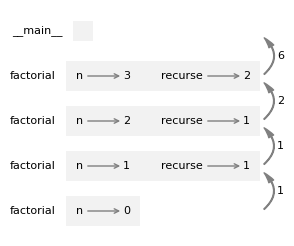

In [3]:
from diagram import diagram, adjust

width, height, x, y = [2.74, 2.26, 0.73, 2.05]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

Los valores de retorno se muestran pasando de vuelta hacia arriba por la pila.
En cada marco, el valor de retorno es el producto de `n` y `recurse`.

En el último marco, la variable local `recurse` no existe porque la rama que la crea no se ejecuta.

## Salto de fe

Seguir el flujo de ejecución es una forma de leer programas, pero puede volverse abrumadora rápidamente. Una alternativa es lo que llamo el "salto de fe". Cuando llegas a una llamada a una función, en lugar de seguir el flujo de ejecución, *asumes* que la función funciona correctamente y devuelve el resultado adecuado.

De hecho, ya estás practicando este salto de fe cuando usas funciones integradas.
Cuando llamas a `abs` o `math.sqrt`, no examinas los cuerpos de esas funciones -- simplemente asumes que funcionan.

Lo mismo ocurre cuando llamas a una de tus propias funciones. Por ejemplo, antes escribimos una función llamada `is_divisible` que determina si un número es divisible por otro. Una vez que nos convencemos de que esta función es correcta, podemos usarla sin volver a mirar el cuerpo.

Lo mismo ocurre con los programas recursivos.
Cuando llegas a la llamada recursiva, en lugar de seguir el flujo de ejecución, deberías asumir que la llamada recursiva funciona y luego preguntarte: "Suponiendo que puedo calcular el factorial de $n-1$, ¿puedo calcular el factorial de $n$?"
La definición recursiva del factorial implica que sí puedes, multiplicando por $n$.

Por supuesto, es un poco extraño asumir que la función funciona correctamente cuando aún no has terminado de escribirla, ¡pero por eso se llama salto de fe!

## Fibonacci

Después de `factorial`, el ejemplo más común de función recursiva es `fibonacci`, que tiene la siguiente definición:

$$egin{aligned}
\mathrm{fibonacci}(0) &= 0 \
\mathrm{fibonacci}(1) &= 1 \
\mathrm{fibonacci}(n) &= \mathrm{fibonacci}(n-1) + \mathrm{fibonacci}(n-2)
\end{aligned}$$

Traducida a Python, se ve así:

In [ ]:
def fibonacci(n):
    if n == 0:
        return 0
    elif  n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

Si intentas seguir aquí el flujo de ejecución, incluso para valores pequeños de $n$, te explota la cabeza.
Pero según el salto de fe, si asumes que las dos llamadas recursivas funcionan correctamente, puedes confiar en que la última sentencia `return` es correcta.

Como nota aparte, esta forma de calcular números de Fibonacci es muy ineficiente.
En el [Capítulo 10](section_memos) explicaré por qué y sugeriré una forma de mejorarla.

## Comprobación de tipos

¿Qué ocurre si llamamos a `factorial` y le damos `1.5` como argumento?

In [ ]:
%%expect RecursionError

factorial(1.5)

Parece una recursión infinita. ¿Cómo puede ser? La función tiene casos base cuando `n == 1` o `n == 0`.
Pero si `n` no es un entero, podemos *saltarnos* el caso base y hacer recursión para siempre.

En este ejemplo, el valor inicial de `n` es `1.5`.
En la primera llamada recursiva, el valor de `n` es `0.5`.
En la siguiente, es `-0.5`.
A partir de ahí, se hace más pequeño (más negativo), pero nunca será `0`.

Para evitar la recursión infinita podemos usar la función integrada `isinstance` para comprobar el tipo del argumento.
Así comprobamos si un valor es un entero.

In [ ]:
isinstance(3, int)

In [ ]:
isinstance(1.5, int)

Ahora aquí tienes una versión de `factorial` con comprobación de errores.

In [ ]:
def factorial(n):
    if not isinstance(n, int):
        print('factorial is only defined for integers.')
        return None
    elif n < 0:
        print('factorial is not defined for negative numbers.')
        return None
    elif n == 0:
        return 1
    else:
        return n * factorial(n-1)

Primero comprueba si `n` es un entero.
Si no lo es, muestra un mensaje de error y devuelve `None`.




In [ ]:
factorial('crunchy frog')

Luego comprueba si `n` es negativo.
Si lo es, muestra un mensaje de error y devuelve `None`.

In [ ]:
factorial(-2)

Si superamos ambas comprobaciones, sabemos que `n` es un entero no negativo, así que podemos confiar en que la recursión terminará.
Comprobar los parámetros de una función para asegurarse de que tienen los tipos y valores correctos se llama **validación de entrada**.

## Debugging

Dividir un programa grande en funciones más pequeñas crea puntos de control naturales para depurar.
Si una función no funciona, hay tres posibilidades que considerar:

-   Hay algo mal con los argumentos que recibe la función -- es decir, se viola una precondición.

-   Hay algo mal con la función -- es decir, se viola una postcondición.

-   Quien llama a la función está haciendo algo mal con el valor de retorno.

Para descartar la primera posibilidad, puedes añadir una sentencia `print` al principio de la función que muestre los valores de los parámetros (y quizá sus tipos).
O puedes escribir código que compruebe explícitamente las precondiciones.

Si los parámetros parecen correctos, puedes añadir una sentencia `print` antes de cada sentencia `return` y mostrar el valor de retorno.
Si es posible, llama a la función con argumentos que faciliten comprobar el resultado.

Si la función parece funcionar, mira la llamada a la función para asegurarte de que el valor de retorno se está usando correctamente -- ¡o de que se está usando siquiera!

Añadir sentencias `print` al principio y al final de una función puede ayudar a hacer más visible el flujo de ejecución.
Por ejemplo, aquí tienes una versión de `factorial` con sentencias print:

In [ ]:
def factorial(n):
    space = ' ' * (4 * n)
    print(space, 'factorial', n)
    if n == 0:
        print(space, 'returning 1')
        return 1
    else:
        recurse = factorial(n-1)
        result = n * recurse
        print(space, 'returning', result)
        return result

`space` es una cadena de caracteres de espacio que controla la indentación de
la salida. Este es el resultado de `factorial(3)` :

In [ ]:
factorial(3)

Si tienes dudas sobre el flujo de ejecución, este tipo de salida puede ser útil.
Lleva tiempo desarrollar andamiaje eficaz, pero un poco de andamiaje puede ahorrar mucho debugging.

## Glosario

**valor de retorno:**
El resultado de una función. Si una llamada a una función se usa como expresión, el valor de retorno es el valor de la expresión.

**función pura:**
Una función que no muestra nada ni tiene ningún otro efecto, aparte de devolver un valor de retorno.


**código muerto:**
Parte de un programa que nunca puede ejecutarse, a menudo porque aparece después de una sentencia `return`.

**desarrollo incremental:**
Un plan de desarrollo de programas pensado para evitar la depuración añadiendo y probando solo una pequeña cantidad de código cada vez.

**andamiaje:**
 Código que se usa durante el desarrollo del programa pero que no forma parte de la versión final.

**Turing completo:**
Un lenguaje, o un subconjunto de un lenguaje, es Turing completo si puede realizar cualquier cálculo que pueda describirse mediante un algoritmo.

**validación de entrada:**
Comprobar los parámetros de una función para asegurarse de que tienen los tipos y valores correctos

## Ejercicios

In [4]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregunta a un asistente virtual

En este capítulo vimos una función incorrecta que puede terminar sin devolver un valor.

In [ ]:
def absolute_value_wrong(x):
    if x < 0:
        return -x
    if x > 0:
        return x

Y una versión de la misma función que tiene código muerto al final.

In [ ]:
def absolute_value_extra_return(x):
    if x < 0:
        return -x
    else:
        return x

    return 'This is dead code.'

Y vimos el siguiente ejemplo, que es correcto pero no idiomático.

In [ ]:
def is_divisible(x, y):
    if x % y == 0:
        return True
    else:
        return False

Pregunta a un asistente virtual qué está mal en cada una de estas funciones y comprueba si puede detectar los errores o mejorar el estilo.

Luego pregunta: "Escribe una función que tome las coordenadas de dos puntos y calcule la distancia entre ellos." Comprueba si el resultado se parece a la versión de `distance` que escribimos en este capítulo.

In [5]:
import math

def distancia(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [6]:
distancia(1, 2, 4, 6)

5.0

### Ejercicio

Usa desarrollo incremental para escribir una función llamada `hypot` que devuelva la longitud de la hipotenusa de un triángulo rectángulo dadas las longitudes de los otros dos catetos como argumentos.

Nota: Hay una función en el módulo math llamada `hypot` que hace lo mismo, ¡pero no deberías usarla para este ejercicio!

Aunque puedas escribir la función correctamente al primer intento, empieza con una función que siempre devuelva `0` y practica haciendo cambios pequeños, probando a medida que avanzas.
Cuando termines, la función solo debería devolver un valor -- no debería mostrar nada.

In [12]:
# Solution goes here
import math
def hypot (l1, l2):
    cat1 = l1**2
    cat2 = l2**2
    suma_cat = cat1 + cat2
    raiz = math.sqrt(suma_cat)

    return raiz


hypot(5, 3)

5.830951894845301

In [11]:
# version simplificada

def hypot (c1, c2):
    hipotenusa = math.sqrt((c1**2)+(c2**2))
    return hipotenusa

hypot(5, 3)


5.830951894845301

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

### Ejercicio

Escribe una función booleana, `is_between(x, y, z)`, que devuelva `True` si $x < y < z$ o si
$z < y < x$, y `False` en caso contrario.

In [13]:
# Solution goes here
def is_between (x, y, z):
    if x < y < z or z < y < x :
       return True
    else:
       return False

In [23]:
# solucion idiomatica
def is_between (x, y, z):
    return x < y < z or z < y < x

Puedes usar estos ejemplos para probar tu función.

In [24]:
is_between(1, 2, 3)  # should be True

True

In [25]:
is_between(3, 2, 1)  # should be True

True

In [21]:
is_between(1, 3, 2)  # should be False

False

In [22]:
is_between(2, 3, 1)  # should be False

False

### Ejercicio

La función de Ackermann, $A(m, n)$, se define así:

$$egin{aligned}
A(m, n) = egin{cases}
              n+1 & \mbox{if } m = 0 \
        A(m-1, 1) & \mbox{if } m > 0 \mbox{ and } n = 0 \
A(m-1, A(m, n-1)) & \mbox{if } m > 0 \mbox{ and } n > 0.
\end{cases}
\end{aligned}$$

Escribe una función llamada `ackermann` que evalúe la función de Ackermann.
¿Qué ocurre si llamas a `ackermann(5, 5)`?

In [26]:
# Solution goes here
def ackermann (m, n):
    if m == 0 :
       a = n + 1
       return a
    elif m > 0 and n == 0:
       b = ackermann(m-1, 1)
       return b
    elif m > 0 and n > 0:
       c = ackermann(m-1, ackermann(m, n-1))
       return c


In [36]:
# Versión simplificada
def ackermann(m, n):
    if m == 0:
        return n + 1
    elif m > 0 and n == 0:
        return ackermann(m - 1, 1)
    else:
        return ackermann(m - 1, ackermann(m, n - 1))

Puedes usar estos ejemplos para probar tu función.

In [48]:
ackermann(2, 1)

5

In [37]:
ackermann(3, 2)  # should be 29

29

In [28]:
ackermann(3, 3)  # should be 61

61

In [34]:
ackermann(3, 4)  # should be 125

125

Si llamas a esta función con valores mayores que 4, obtienes un `RecursionError`.

In [30]:
%%expect RecursionError

ackermann(5, 5)


KeyboardInterrupt



Para ver por qué, añade una sentencia print al principio de la función para mostrar los valores de los parámetros, y luego ejecuta los ejemplos de nuevo.

### Ejercicio

Un número, $a$, es una potencia de $b$ si es divisible por $b$ y $a/b$ es
una potencia de $b$. Escribe una función llamada `is_power` que tome los parámetros
`a` y `b`, y devuelva `True` si `a` es una potencia de `b`. Nota: tendrás
que pensar en el caso base.

In [72]:
# Solution goes here
def is_power (a, b):
    if a == 1:
       return True
    elif a % b == 0 and is_power(a // b, b):
       return True
    else:
      return False


Puedes usar estos ejemplos para probar tu función.

In [73]:
is_power(65536, 2)   # should be True

True

In [74]:
is_power(27, 3)  # should be True

True

In [75]:
is_power(24, 2)  # should be False

False

In [76]:
is_power(1, 17)   # should be True

True

### Ejercicio

El máximo común divisor (MCD) de $a$ y $b$ es el número más grande
que divide a ambos sin dejar resto.

Una forma de encontrar el MCD de dos números se basa en la observación de que
si $r$ es el resto cuando $a$ se divide por $b$, entonces $gcd(a,
b) = gcd(b, r)$. Como caso base, podemos usar $gcd(a, 0) = a$.

Escribe una función llamada `gcd` que tome los parámetros `a` y `b`, y
devuelva su máximo común divisor.

In [78]:
# Solution goes here
def gcd (a, b):
    if b == 0:
       return a
    else:
       r = a % b
       return gcd(b, r)

Puedes usar estos ejemplos para probar tu función.

In [79]:
gcd(12, 8)    # should be 4

4

In [80]:
gcd(13, 17)   # should be 1

1

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Licencia del código: [MIT License](https://mit-license.org/)

Licencia del texto: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)